#Решении задачи классификации на датасете mnist

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [ ]:
# Трансформации для MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Грузанули MNIST
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Разделение train на train/val (50k / 10k)
train_subset, val_subset = random_split(
    train_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 52.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.24MB/s]


Train: 50000, Val: 10000, Test: 10000


Первая модель Model1_MLP представляет собой простейшую полносвязную сеть, которая не учитывает двумерную структуру изображения.
В ней есть слой **Flatten**, преобразующий многомерные данные в плоский вектор.

На вход модель получает тензор размерности [batch, 1, 28, 28]. Flatten() преобразует каждую картинку в плоский вектор длиной 28 * 28 = 784.

Далее данные проходят через два линейных слоя с функцией активации ReLU:
  1) Linear(784 -> 128) — сжимает входной вектор до 128 признаков.
  2) Linear(128 -> 10) — формирует выходной вектор размерности 10,  соответствующий вероятностям принадлежности к классам цифр от 0 до 9.

Число 128 здесь гиперпараметр, выбранный эмпирически. Оно является стандартным для подобных задач и встречается во многих учебных примерах.Насколько понимаю, оно подобрано с учётом хорошей получаемой точности модели и позволяет избежать переобучения.

Схемка:

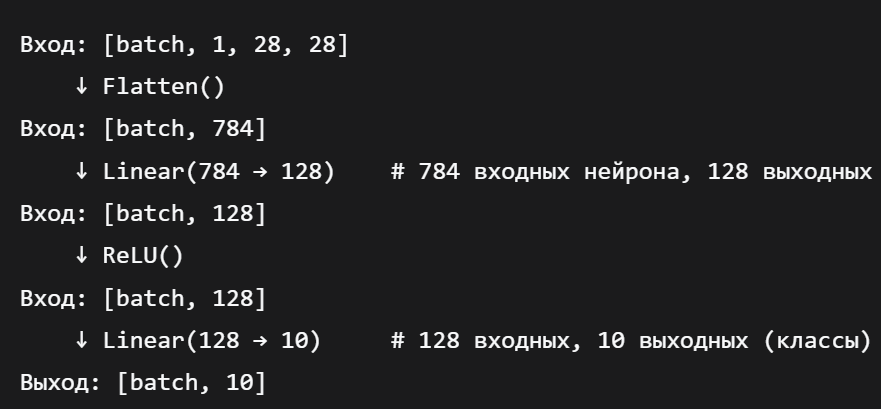


In [ ]:
class Model1_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

Данная архитектура самая простая и не учитывает пространственную структуру изображений. Поэтому ожидается, что она покажет наименьшую точность.

Дальше будем её улучшать и переделывать, добавляя dropout и batchnorm, а также другие функции активации и уже в скрытых слоях.

Модель Model2_SimpleCNN - это уже простая свёрточная нейросеть, в которой мы учтём, что изображение двумерное, использовав свёрточные слои.

Что из себя представляет эта модель: **свёрточная часть (признаки) + классификатор (полносвязная часть).**

В свёрточной части следующие слои:
  1) Conv2d(1 -> 32, kernel=3, padding=1) — первый свёрточный слой с 32 фильтрами размера 3×3. Сохраняет размер изображения (28×28) за счёт паддинга.

  2) ReLU() — нелинейная активация.

  3) MaxPool2d(2) — уменьшает размер в 2 раза (28 -> 14).

  4) Conv2d(32 -> 64, kernel=3, padding=1) — второй свёрточный слой, увеличивает количество фильтров до 64. Размер остаётся 14*14.

  5) ReLU() — активация.

  6) MaxPool2d(2) — снова уменьшает размер (14 -> 7).

Классификатор:

  1) Flatten() — преобразует трёхмерный тензор [batch, 64, 7, 7] в плоский вектор длиной 64 × 7 × 7 = 3136.

  2) Linear(3136 -> 128) — полносвязный слой, сжимающий признаки до 128.

  3) ReLU() — функция активации.

  4) Linear(128 -> 10) — выходной слой, соответствующий 10 классам цифр.

Количество фильтров увеличивается с глубиной (32 - 64), что позволяет сети выделять сначала простые признаки (края, линии), а затем более сложные (формы, части цифр).

Модель пока не содержит BatchNorm и Dropout, чтобы показать эффективность этих методов в следующих двух моделях (если конкретнее, то в последней модели будут использоваться оба этих метода).

Это схемка работы модели по слоям:
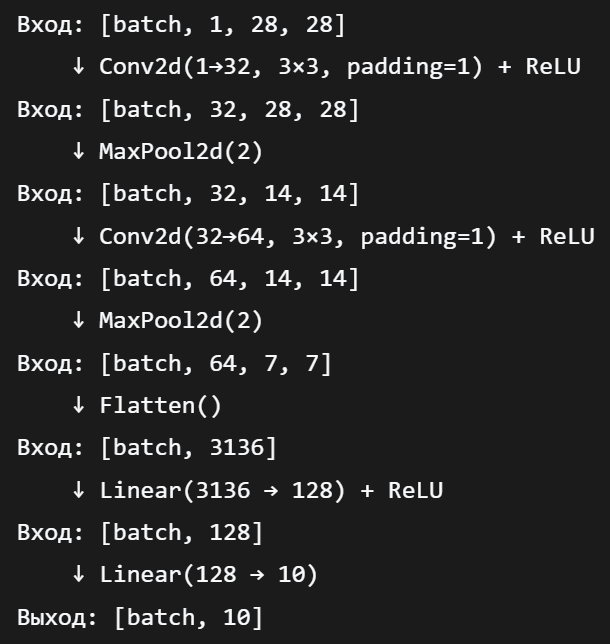


In [ ]:
class Model2_SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

Модель показала улучшение точности по сравнению с MLP, поскольку учли двумерность изображения. Но есть проблема на графиках обучения (долистать до конца тетрадки, будет картинка) видно расхождение между train и val loss — это признак переобучения. Значит надо добавлять BatchNorm.

Модель Model3_CNN_BN повторяет архитектуру предыдущей свёрточной сети, но дополнена слоями BatchNorm2d с соответствующим количеством каналов после каждого свёрточного слоя.

Главная цель этих слоёв снизить переобучение.

И схемка:

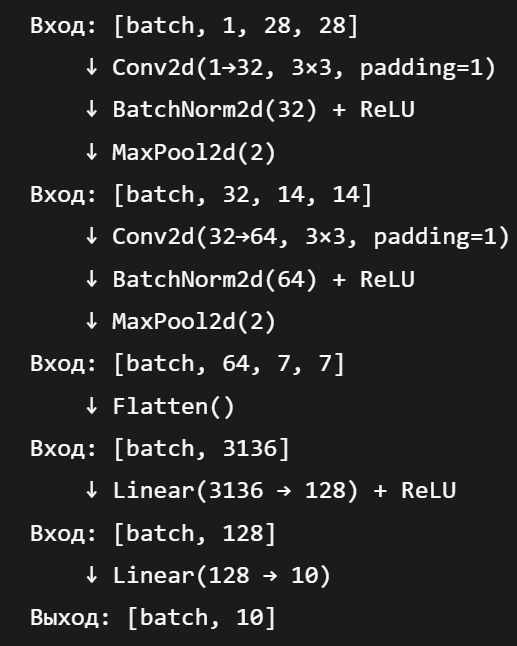

In [ ]:
class Model3_CNN_BN(nn.Module):
    """CNN + BatchNorm"""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Model4_CNN_Full(nn.Module):
    """CNN + BatchNorm + Dropout (по идее, должна лучше всех работать,
    но это мы ещё проверим"""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# сделала словарик, чтобы удобно было перебирать модельки
models = {
    '1_MLP': Model1_MLP,
    '2_SimpleCNN': Model2_SimpleCNN,
    '3_CNN_BN': Model3_CNN_BN,
    '4_CNN_Full': Model4_CNN_Full
}

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(output, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            output = model(X)
            loss = criterion(output, y)

            total_loss += loss.item()
            _, predicted = torch.max(output, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return (total_loss / len(loader),
            100. * correct / total,
            all_preds,
            all_labels)

In [ ]:
def get_description(name):
    descriptions = {
        '1_MLP': 'Полносвязная сеть, не учитывает 2D-структуру',
        '2_SimpleCNN': 'Простая CNN, учитывает 2D, без регуляризации',
        '3_CNN_BN': 'CNN + BatchNorm для стабилизации',
        '4_CNN_Full': 'CNN + BatchNorm + Dropout, полная регуляризация'
    }
    return descriptions.get(name, '')


results = []
training_history = {}  # Словарь для хранения истории каждой модели

NUM_EPOCHS = 5  # Для быстрого эксперимента можно 3-5 эпох

for name, model_class in models.items():
    print(f"\n{'=' * 50}")
    print(f"Обучаем модель: {name}")
    print('=' * 50)

    # Создаем модель
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Для хранения истории
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    epochs_list = []

    # Обучение
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        epochs_list.append(epoch + 1)

        print(
            f'Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    # Сохраняем историю для графиков
    training_history[name] = {
        'epochs': epochs_list,
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accs,
        'val_acc': val_accs
    }

    # Финальная оценка на тесте
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

    # Считаем метрики
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)

    precision = precision_score(test_labels, test_preds, average='macro')
    recall = recall_score(test_labels, test_preds, average='macro')
    f1 = f1_score(test_labels, test_preds, average='macro')

    # Сохраняем результаты
    results.append({
        'Model': name,
        'Val Loss': min(val_losses),
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Description': get_description(name)
    })

    print(f"\n✅ Результаты {name}:")
    print(f"   Test Acc: {test_acc:.2f}%, F1: {f1:.4f}")


df = pd.DataFrame(results)
df = df[['Model', 'Val Loss', 'Test Acc', 'Precision', 'Recall', 'F1', 'Description']]
print("\n" + "=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 80)
print(df.to_string(index=False))


Обучаем модель: 1_MLP
Epoch 1: Train Loss: 0.2787, Train Acc: 91.80% | Val Loss: 0.1589, Val Acc: 95.27%
Epoch 2: Train Loss: 0.1183, Train Acc: 96.57% | Val Loss: 0.1238, Val Acc: 96.18%
Epoch 3: Train Loss: 0.0815, Train Acc: 97.55% | Val Loss: 0.1145, Val Acc: 96.45%
Epoch 4: Train Loss: 0.0608, Train Acc: 98.12% | Val Loss: 0.0946, Val Acc: 97.00%
Epoch 5: Train Loss: 0.0472, Train Acc: 98.55% | Val Loss: 0.0883, Val Acc: 97.41%

✅ Результаты 1_MLP:
   Test Acc: 97.55%, F1: 0.9754

Обучаем модель: 2_SimpleCNN
Epoch 1: Train Loss: 0.1471, Train Acc: 95.52% | Val Loss: 0.0538, Val Acc: 98.55%
Epoch 2: Train Loss: 0.0434, Train Acc: 98.66% | Val Loss: 0.0492, Val Acc: 98.40%
Epoch 3: Train Loss: 0.0309, Train Acc: 99.00% | Val Loss: 0.0485, Val Acc: 98.75%
Epoch 4: Train Loss: 0.0215, Train Acc: 99.30% | Val Loss: 0.0459, Val Acc: 98.68%
Epoch 5: Train Loss: 0.0156, Train Acc: 99.50% | Val Loss: 0.0444, Val Acc: 98.83%

✅ Результаты 2_SimpleCNN:
   Test Acc: 99.11%, F1: 0.9910

Обуча

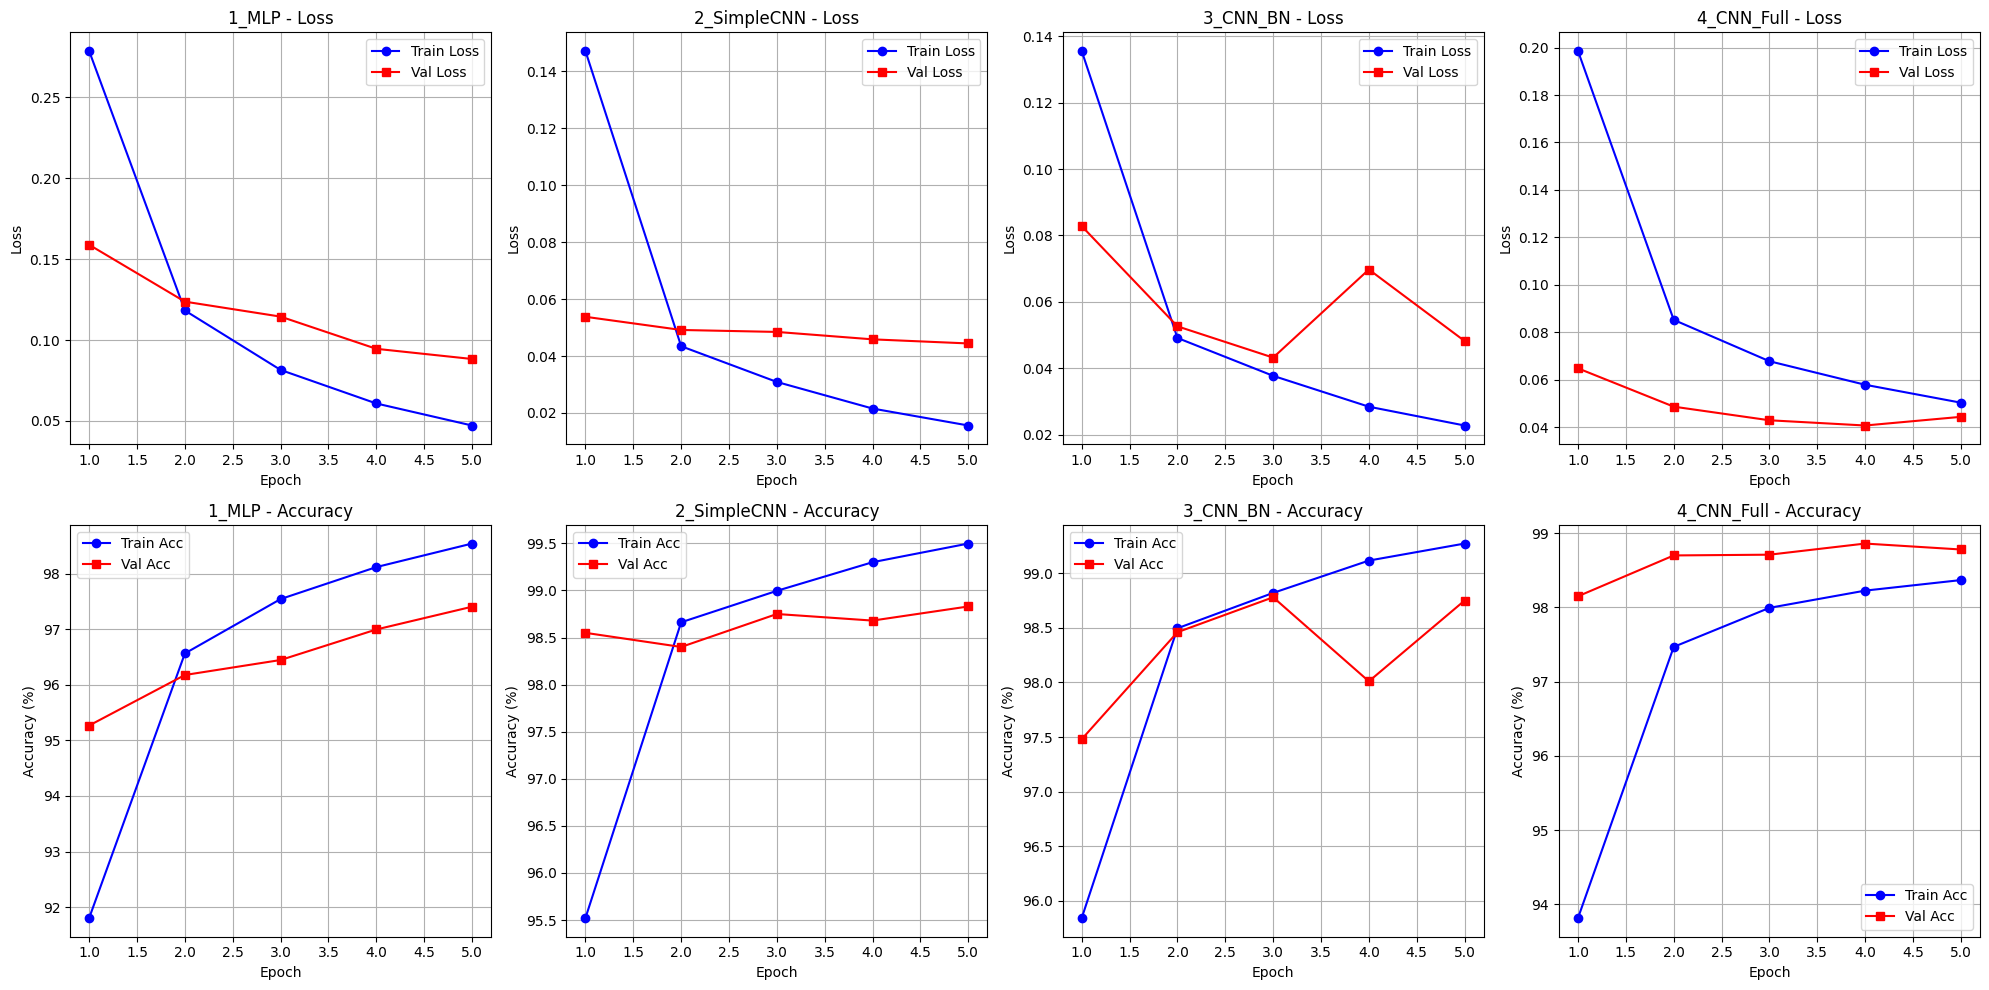

In [ ]:
# ГРАФИКИ ОБУЧЕНИЯ ДЛЯ КАЖДОЙ МОДЕЛИ
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
colors = ['gray', 'lightblue', 'skyblue', 'steelblue']

for idx, (name, history) in enumerate(training_history.items()):
    # График Loss
    ax_loss = axes[0, idx]
    ax_loss.plot(history['epochs'], history['train_loss'], 'o-', label='Train Loss', color='blue')
    ax_loss.plot(history['epochs'], history['val_loss'], 's-', label='Val Loss', color='red')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'{name} - Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # График Accuracy
    ax_acc = axes[1, idx]
    ax_acc.plot(history['epochs'], history['train_acc'], 'o-', label='Train Acc', color='blue')
    ax_acc.plot(history['epochs'], history['val_acc'], 's-', label='Val Acc', color='red')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy (%)')
    ax_acc.set_title(f'{name} - Accuracy')
    ax_acc.legend()
    ax_acc.grid(True)

plt.tight_layout()
plt.show()

На графиках обучения (Loss и Accuracy по эпохам) для каждой из четырёх моделей можно проследить, как архитектурные изменения влияют на процесс обучения и обобщающую способность.

**Модель 1 (MLP)**: Демонстрирует медленную сходимость и значительный разрыв между кривыми обучения и валидации. Это классический признак переобучения: модель хорошо запоминает обучающие данные, но не может обобщить знания на новые примеры из-за игнорирования пространственной структуры изображений.

**Модель 2 (SimpleCNN)**: Переход к свёрточной архитектуре резко ускоряет сходимость. Однако сохраняется заметный разрыв между train и val графиками, что указывает на то, что модель, хоть и учитывает двумерность данных, по-прежнему склонна к переобучению.

**Модель 3 (CNN + BatchNorm)**: Добавление слоёв нормализации по батчам делает графики обучения более стабильными и гладкими. Разрыв между train и val loss заметно сокращается, что подтверждает эффективность BatchNorm в борьбе с переобучением и его роль в стабилизации обучения.

**Модель 4 (CNN + BatchNorm + Dropout**): Эта архитектура показывает наилучший результат. Разрыв между кривыми обучения и валидации минимален, а качество на валидации — самое высокое. Это наглядно демонстрирует, как комбинация BatchNorm и Dropout позволяет модели не только быстро и стабильно обучаться, но и эффективно обобщать знания, избегая переобучения.



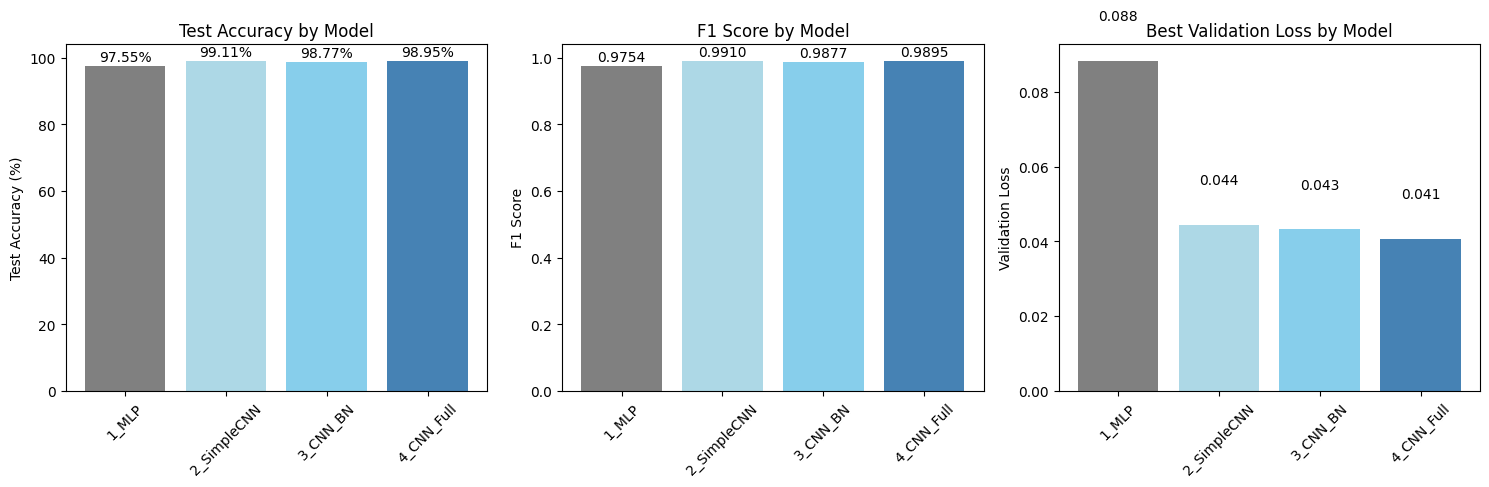

In [ ]:
plt.figure(figsize=(15, 5))

# График Test Accuracy
plt.subplot(1, 3, 1)
models_names = [r['Model'] for r in results]
test_accs = [r['Test Acc'] for r in results]
bars = plt.bar(models_names, test_accs, color=['gray', 'lightblue', 'skyblue', 'steelblue'])
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy by Model')
plt.xticks(rotation=45)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom')

# График F1-score
plt.subplot(1, 3, 2)
f1_scores = [r['F1'] for r in results]
bars = plt.bar(models_names, f1_scores, color=['gray', 'lightblue', 'skyblue', 'steelblue'])
plt.ylabel('F1 Score')
plt.title('F1 Score by Model')
plt.xticks(rotation=45)
for bar, f1 in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{f1:.4f}', ha='center', va='bottom')

# График Val Loss
plt.subplot(1, 3, 3)
val_losses = [r['Val Loss'] for r in results]
bars = plt.bar(models_names, val_losses, color=['gray', 'lightblue', 'skyblue', 'steelblue'])
plt.ylabel('Validation Loss')
plt.title('Best Validation Loss by Model')
plt.xticks(rotation=45)
for bar, loss in zip(bars, val_losses):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{loss:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

В ходе выполнения работы были реализованы и исследованы четыре архитектуры нейронных сетей для задачи классификации рукописных цифр MNIST: от простой полносвязной модели до свёрточной сети с полной регуляризацией.

Тесты показали, что:

  1) Учёт пространственной структуры изображений (переход от MLP к CNN) критически важен для качества классификации.

  2) Использование BatchNorm стабилизирует обучение, ускоряет сходимость и снижает переобучение.

  3) Применение Dropout дополнительно улучшает обобщающую способность модели, минимизируя разрыв между обучением и валидацией.

Лучший результат показала модель Model4_CNN_Full, сочетающая свёрточные слои, BatchNorm и Dropout. Именно эта архитектура обеспечила наивысшую точность на тестовой выборке и наименьшую ошибку на валидации, продемонстрировав оптимальный баланс между выразительной способностью и устойчивостью к переобучению.

Примечание (теперь некрасивый и более простой общий вывод): чем более сложные данные мы хотим обрабаботать и классифицировать, тем более сложная и глубокая должна быть нейросеть. Но при этом важно следить за переобучением и предотвращать его на опредённых слоях обработки данных.